## Importing Necessary

In [1]:
import os 
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer

# for processing and feature engineering 

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)

from sklearn.feature_selection import (
    SelectKBest,
    SelectPercentile,
    RFE,
    RFECV,
    VarianceThreshold
)


from sklearn.preprocessing import(
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    Normalizer,
    PolynomialFeatures,
    OrdinalEncoder,
    LabelEncoder,
    KBinsDiscretizer,
    FunctionTransformer
)

# Model Selection and Evaluation


from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold,
    cross_validate
)


from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_squared_error,
    confusion_matrix,
    r2_score,
    classification_report,
    f1_score,
    recall_score,
    explained_variance_score,
    precision_score
)


# for regression


from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    SGDRegressor,
    PassiveAggressiveRegressor
)


from sklearn.tree import (
    DecisionTreeRegressor,
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor,
    BaggingRegressor
)


from sklearn.svm import(
    SVR,
    LinearSVR
)

from sklearn.neighbors import (
    KNeighborsRegressor,
)

from sklearn.neural_network import (
    MLPRegressor,
    _multilayer_perceptron
)


# for classification
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    Perceptron,
    PassiveAggressiveClassifier,
    SGDClassifier
)

from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)


from sklearn.svm import (
    SVC,
    LinearSVR,
    NuSVC
)


from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    CategoricalNB,
    ComplementNB
)

from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)

from sklearn.impute import IterativeImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


import scipy.stats as stats

from scipy.stats import (
    anderson,
    jarque_bera,
    shapiro,
    normaltest,
    kstest
)

from statsmodels.stats.diagnostic import lilliefors

from scipy.stats import zscore

from sklearn.feature_extraction import FeatureHasher

from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin

### Loading DataSets

In [2]:
path = os.path.join('..','data','raw','used_cars.csv')
print(path)

..\data\raw\used_cars.csv


In [3]:
df = pd.read_csv(path)

### Basic Initial Inspection

In [4]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_colwidth',None)
df.head(1)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"


In [5]:
df.tail(1)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [6]:
df.sample()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
428,Lincoln,MKS EcoBoost,2016,"38,100 mi.",Gasoline,365.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,None reported,Yes,"$21,000"


In [7]:
df.describe(include='all')

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print(f"The memory consumed in RAM is {(df.memory_usage(deep=True)/(1024*1024)).sum():.3f} MB")

The memory consumed in RAM is 0.872 MB


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [10]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [11]:
df['milage']=(
    df['milage']
    .str.replace(',','')
    .str.replace('mi.','')
    .astype(float)
)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   str    
 1   model         4009 non-null   str    
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   str    
 5   engine        4009 non-null   str    
 6   transmission  4009 non-null   str    
 7   ext_col       4009 non-null   str    
 8   int_col       4009 non-null   str    
 9   accident      3896 non-null   str    
 10  clean_title   3413 non-null   str    
 11  price         4009 non-null   str    
dtypes: float64(1), int64(1), str(10)
memory usage: 853.2 KB


In [13]:
df['price'] = (
    df['price']
    .astype(str)             
    .str.replace('$', '')    
    .str.replace(',', '')    
    .astype(float)           
)

In [14]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


In [15]:
df['Accdent_Occured']=(
    df['accident']
    .apply(lambda x: "NO" if x=='None reported' else "YES")
)

In [16]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,NO
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,NO


In [17]:
df['Engine_Capacity']=(
    df['engine']
    .str.extract(r'(\d+\.\d+L|\d+L|\d+\.\d+\s+Liter|\d+\s+Liter)')
)

In [18]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES,3.7L
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES,3.8L
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,NO,3.5 Liter
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO,3.5L
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,NO,2.0L


In [19]:
df['Horse_Power']=(
    df['engine']
    .str.extract(r'(\d+\.\d+HP|\d+HP)')
)

In [20]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES,3.7L,300.0HP
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES,3.8L,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,NO,3.5 Liter,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO,3.5L,354.0HP
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,NO,2.0L,NaN


In [21]:
df['Engine_Capacity'] = (
    df['Engine_Capacity']
    .astype(str)  
    .str.replace('Liter', '', regex=False)
    .str.replace('L', '', regex=False)
    .str.strip()  
    .astype(float)  
)


In [22]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES,3.7,300.0HP
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,NO,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO,3.5,354.0HP
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,NO,2.0,NaN


In [23]:
df['Horse_Power']=(
    df['Horse_Power']
    .astype(str)
    .str.replace('HP','')
    .astype(float)
)

In [24]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,NO,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,NO,2.0,NaN


### Handling Missing Values

In [25]:
df.isnull().sum()

brand                0
model                0
model_year           0
milage               0
fuel_type          170
engine               0
transmission         0
ext_col              0
int_col              0
accident           113
clean_title        596
price                0
Accdent_Occured      0
Engine_Capacity    219
Horse_Power        808
dtype: int64

In [26]:
missing_info={}
for col in df.columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The columns with the missing percentage are:

fuel_type:4.24%
accident:2.82%
clean_title:14.87%
Engine_Capacity:5.46%
Horse_Power:20.15%


In [27]:
df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,NO,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,NO,2.0,NaN


In [28]:
Categorical_columns=df.select_dtypes(include=['object','category']).columns
Numerical_columns= df.select_dtypes(include=['number','int64','int32','float64','float32']).columns

C:\Users\sauju\AppData\Local\Temp\ipykernel_20300\3204705995.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_columns=df.select_dtypes(include=['object','category']).columns


In [29]:
df[Categorical_columns].head()

,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,Accdent_Occured
0,Ford,Utility Police Interceptor Base,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,YES
1,Hyundai,Palisade SEL,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,YES
2,Lexus,RX 350 RX 350,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,NO
3,INFINITI,Q50 Hybrid Sport,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,NO
4,Audi,Q3 45 S line Premium Plus,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,NO


In [30]:
df[Numerical_columns].head()

,model_year,milage,price,Engine_Capacity,Horse_Power
0,2013,51000.0,10300.0,3.7,300.0
1,2021,34742.0,38005.0,3.8,NaN
2,2022,22372.0,54598.0,3.5,NaN
3,2015,88900.0,15500.0,3.5,354.0
4,2021,9835.0,34999.0,2.0,NaN


In [31]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

fuel_type:4.24%
accident:2.82%
clean_title:14.87%


In [32]:
df['clean_title'].value_counts()

clean_title
Yes    3413
Name: count, dtype: int64

In [33]:
df['clean_title'].head()

0    Yes
1    Yes
2    NaN
3    Yes
4    NaN
Name: clean_title, dtype: str

In [34]:
df['clean_title']= df['clean_title'].fillna('unknown')

In [35]:
df['clean_title'].head()

0        Yes
1        Yes
2    unknown
3        Yes
4    unknown
Name: clean_title, dtype: str

In [36]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")
    


 The categorical columns with the missing percentage are:

fuel_type:4.24%
accident:2.82%


In [37]:
df[['brand','model','transmission','engine','fuel_type']].head(50)

,brand,model,transmission,engine,fuel_type
0,Ford,Utility Police Interceptor Base,6-Speed A/T,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,E85 Flex Fuel
1,Hyundai,Palisade SEL,8-Speed Automatic,3.8L V6 24V GDI DOHC,Gasoline
2,Lexus,RX 350 RX 350,Automatic,3.5 Liter DOHC,Gasoline
3,INFINITI,Q50 Hybrid Sport,7-Speed A/T,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,Hybrid
4,Audi,Q3 45 S line Premium Plus,8-Speed Automatic,2.0L I4 16V GDI DOHC Turbo,Gasoline
5,Acura,ILX 2.4L,F,2.4 Liter,Gasoline
6,Audi,S3 2.0T Premium Plus,6-Speed A/T,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Gasoline
7,BMW,740 iL,A/T,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,Gasoline
8,Lexus,RC 350 F Sport,6-Speed A/T,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Gasoline
9,Tesla,Model X Long Range Plus,A/T,534.0HP Electric Motor Electric Fuel System,NaN


In [38]:
df.loc[df['engine'].str.contains('Electric Motor Electric Fuel System', case= False, na= False),['brand','model','engine','transmission','fuel_type']]


,brand,model,engine,transmission,fuel_type
9,Tesla,Model X Long Range Plus,534.0HP Electric Motor Electric Fuel System,A/T,NaN
44,Lucid,Air Grand Touring,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,NaN
68,Lucid,Air Grand Touring,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,NaN
92,Rivian,R1S Adventure Package,835.0HP Electric Motor Electric Fuel System,1-Speed A/T,NaN
122,Rivian,R1S Adventure Package,835.0HP Electric Motor Electric Fuel System,A/T,NaN
129,Lucid,Air Pure,620.0HP Electric Motor Electric Fuel System,A/T,NaN
155,Tesla,Model 3 Performance,455.0HP Electric Motor Electric Fuel System,A/T,NaN
189,Tesla,Model Y Performance,455.0HP Electric Motor Electric Fuel System,1-Speed A/T,NaN
225,Tesla,Model X Base,670.0HP Electric Motor Electric Fuel System,A/T,NaN
253,Mercedes-Benz,EQS 450 4MATIC,355.0HP Electric Motor Electric Fuel System,1-Speed A/T,NaN


In [39]:
df['fuel_type']= df['fuel_type'].where(~df['engine'].str.contains('ELectric Motor Electric Fuel System',case=False,na=False),df['fuel_type'].fillna('Electric'))

In [40]:
df.loc[df['engine'].str.contains('Electric Motor Electric Fuel System', case= False, na= False),['brand','model','engine','transmission','fuel_type']]


,brand,model,engine,transmission,fuel_type
9,Tesla,Model X Long Range Plus,534.0HP Electric Motor Electric Fuel System,A/T,Electric
44,Lucid,Air Grand Touring,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
68,Lucid,Air Grand Touring,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
92,Rivian,R1S Adventure Package,835.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
122,Rivian,R1S Adventure Package,835.0HP Electric Motor Electric Fuel System,A/T,Electric
129,Lucid,Air Pure,620.0HP Electric Motor Electric Fuel System,A/T,Electric
155,Tesla,Model 3 Performance,455.0HP Electric Motor Electric Fuel System,A/T,Electric
189,Tesla,Model Y Performance,455.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
225,Tesla,Model X Base,670.0HP Electric Motor Electric Fuel System,A/T,Electric
253,Mercedes-Benz,EQS 450 4MATIC,355.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric


In [41]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

fuel_type:0.6%
accident:2.82%


In [42]:
df.loc[df['engine'].str.contains('Electric Motor Electric Fuel System', case= False, na= False),['brand','model','engine','transmission','fuel_type']]


,brand,model,engine,transmission,fuel_type
9,Tesla,Model X Long Range Plus,534.0HP Electric Motor Electric Fuel System,A/T,Electric
44,Lucid,Air Grand Touring,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
68,Lucid,Air Grand Touring,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
92,Rivian,R1S Adventure Package,835.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
122,Rivian,R1S Adventure Package,835.0HP Electric Motor Electric Fuel System,A/T,Electric
129,Lucid,Air Pure,620.0HP Electric Motor Electric Fuel System,A/T,Electric
155,Tesla,Model 3 Performance,455.0HP Electric Motor Electric Fuel System,A/T,Electric
189,Tesla,Model Y Performance,455.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric
225,Tesla,Model X Base,670.0HP Electric Motor Electric Fuel System,A/T,Electric
253,Mercedes-Benz,EQS 450 4MATIC,355.0HP Electric Motor Electric Fuel System,1-Speed A/T,Electric


In [43]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

fuel_type:0.6%
accident:2.82%


In [44]:
df['fuel_type']=(df['fuel_type'].where(~df['engine'].str.contains('Electric|Dual Motor - Standard|Dual AC Electric Motors|111.2Ah / FR 70kW / RR 160kW (697V)|Standard Range Battery',case=False,na=False),df['fuel_type'].fillna('Electric')))

C:\Users\sauju\AppData\Local\Temp\ipykernel_20300\3238817940.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['fuel_type']=(df['fuel_type'].where(~df['engine'].str.contains('Electric|Dual Motor - Standard|Dual AC Electric Motors|111.2Ah / FR 70kW / RR 160kW (697V)|Standard Range Battery',case=False,na=False),df['fuel_type'].fillna('Electric')))


In [45]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

fuel_type:0.02%
accident:2.82%


In [46]:
df[df['fuel_type'].isna()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
456,Kia,EV6 Wind,2022,11945.0,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Automatic,Glacier,Black,None reported,unknown,38998.0,NO,NaN,NaN


In [47]:
df.loc[456,'fuel_type'] = 'Electric'


In [48]:
df[df['fuel_type'].isna()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power


In [49]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

accident:2.82%


In [50]:
df[['brand', 'engine', 'model', 'fuel_type','accident','clean_title']][df['accident'].isnull()]

,brand,engine,model,fuel_type,accident,clean_title
20,Genesis,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,GV70 3.5T Sport,Gasoline,NaN,unknown
89,Subaru,165.0HP 2.5L 4 Cylinder Engine Gasoline Fuel,Forester 2.5 X,Gasoline,NaN,unknown
128,Audi,280.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Q7 3.0T Premium Plus,Gasoline,NaN,unknown
129,Lucid,620.0HP Electric Motor Electric Fuel System,Air Pure,Electric,NaN,unknown
131,Audi,265.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,TTS 2.0T Premium Plus,Gasoline,NaN,unknown
139,Porsche,400.0HP 3.8L Flat 6 Cylinder Engine Gasoline Fuel,911 Carrera S,Gasoline,NaN,unknown
224,Maserati,404.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Ghibli S Q4,Gasoline,NaN,unknown
235,BMW,560.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,M6 Base,Gasoline,NaN,unknown
357,Mercedes-Benz,188.0HP 3.0L V6 Cylinder Engine Diesel Fuel,Sprinter 4500 High Roof,Diesel,NaN,unknown
376,Hyundai,2.5L I4 16V PDI DOHC,Santa Fe SEL,Gasoline,NaN,unknown


In [51]:
df['accident']=df['accident'].fillna('unknown')

In [52]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,YES,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,unknown,54598.0,NO,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,NO,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,unknown,34999.0,NO,2.0,NaN


In [53]:
missing_info={}
for col in Categorical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:



In [54]:
missing_info={}
for col in Numerical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

Engine_Capacity:5.46%
Horse_Power:20.15%


In [55]:
df[['brand','engine','model','fuel_type','Engine_Capacity','accident','clean_title']][df['Engine_Capacity'].isnull()]

,brand,engine,model,fuel_type,Engine_Capacity,accident,clean_title
9,Tesla,534.0HP Electric Motor Electric Fuel System,Model X Long Range Plus,Electric,NaN,None reported,Yes
10,Land,V6,Rover Range Rover Sport 3.0 Supercharged HST,Gasoline,NaN,None reported,unknown
32,BMW,120 AH,i3 120Ah w/Range Extender,Hybrid,NaN,None reported,unknown
44,Lucid,536.0HP Electric Motor Electric Fuel System,Air Grand Touring,Electric,NaN,None reported,Yes
68,Lucid,536.0HP Electric Motor Electric Fuel System,Air Grand Touring,Electric,NaN,None reported,Yes
92,Rivian,835.0HP Electric Motor Electric Fuel System,R1S Adventure Package,Electric,NaN,None reported,Yes
120,Land,V6,Rover Range Rover Sport 3.0L Supercharged HSE,Gasoline,NaN,At least 1 accident or damage reported,unknown
122,Rivian,835.0HP Electric Motor Electric Fuel System,R1S Adventure Package,Electric,NaN,None reported,Yes
129,Lucid,620.0HP Electric Motor Electric Fuel System,Air Pure,Electric,NaN,unknown,unknown
130,Chrysler,–,Pacifica Touring,–,NaN,None reported,Yes


In [56]:
df[df['Engine_Capacity'].isnull()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
9,Tesla,Model X Long Range Plus,2020,34000.0,Electric,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,69950.0,NO,NaN,534.0
10,Land,Rover Range Rover Sport 3.0 Supercharged HST,2021,27608.0,Gasoline,V6,Automatic,Fuji White,Pimento / Ebony,None reported,unknown,73897.0,NO,NaN,NaN
32,BMW,i3 120Ah w/Range Extender,2020,35035.0,Hybrid,120 AH,Automatic,Black,Black,None reported,unknown,24998.0,NO,NaN,NaN
44,Lucid,Air Grand Touring,2022,3552.0,Electric,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Red,Beige,None reported,Yes,119999.0,NO,NaN,536.0
68,Lucid,Air Grand Touring,2022,4900.0,Electric,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Red,Black,None reported,Yes,99000.0,NO,NaN,536.0
92,Rivian,R1S Adventure Package,2023,2800.0,Electric,835.0HP Electric Motor Electric Fuel System,1-Speed A/T,White,Green,None reported,Yes,92000.0,NO,NaN,835.0
120,Land,Rover Range Rover Sport 3.0L Supercharged HSE,2018,104700.0,Gasoline,V6,Automatic,Fuji White,Ivory / Ebony,At least 1 accident or damage reported,unknown,30775.0,YES,NaN,NaN
122,Rivian,R1S Adventure Package,2023,2500.0,Electric,835.0HP Electric Motor Electric Fuel System,A/T,Green,White,None reported,Yes,94000.0,NO,NaN,835.0
129,Lucid,Air Pure,2023,1300.0,Electric,620.0HP Electric Motor Electric Fuel System,A/T,Black,Gray,unknown,unknown,86900.0,YES,NaN,620.0
130,Chrysler,Pacifica Touring,2017,87305.0,–,–,9-Speed A/T,Silver,Black,None reported,Yes,9000.0,NO,NaN,NaN


In [64]:
df['Engine_Capacity'] = df['Engine_Capacity'].where(
    ~df['transmission'].str.contains('A/T|Automatic', case=False, na=False),
    df['Engine_Capacity'].fillna(0)
)

In [65]:
missing_info={}
for col in Numerical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

Horse_Power:20.15%


In [59]:
df['Engine_Capacity']= df['Engine_Capacity'].where(
    ~df['fuel_type'].str.contains('Electric',case=False, na=False),
    df['Engine_Capacity'].fillna(0)
)

In [60]:
df[df['Engine_Capacity'].isnull()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accdent_Occured,Engine_Capacity,Horse_Power
855,Ford,Bronco,1974,6217.0,–,–,–,Dark Gray Metallic,–,None reported,Yes,115000.0,NO,NaN,NaN
923,Dodge,Challenger R/T,2010,100100.0,–,–,Transmission w/Dual Shift Mode,Purple,Black,None reported,Yes,17000.0,NO,NaN,NaN
995,Dodge,Challenger R/T Scat Pack,2019,43000.0,–,–,6-Speed M/T,Green,Black,None reported,Yes,50000.0,NO,NaN,NaN
1088,Mazda,MX-5 Miata Base,1992,125800.0,–,–,5-Speed M/T,Red,Black,None reported,Yes,11500.0,NO,NaN,NaN
1269,Dodge,Challenger R/T Scat Pack,2016,7928.0,–,–,6-Speed M/T,Red,Red,None reported,Yes,37500.0,NO,NaN,NaN
1615,Rolls-Royce,Phantom,2023,1560.0,–,–,–,Tempest,Cobalt Blue,None reported,Yes,599995.0,NO,NaN,NaN
1681,Acura,Integra GS-R,1995,123000.0,–,–,5-Speed M/T,White,Blue,None reported,Yes,10999.0,NO,NaN,NaN
1746,Nissan,300ZX Base,1993,168000.0,–,–,5-Speed M/T,White,Black,None reported,Yes,7000.0,NO,NaN,NaN
1805,Mercury,Capri XR2,1993,120644.0,–,–,5-Speed M/T,Green,Gray,None reported,Yes,4200.0,NO,NaN,NaN
1956,Nissan,240SX Base,1996,160490.0,–,–,5-Speed M/T,Gray,Black,None reported,Yes,15500.0,NO,NaN,NaN


In [61]:
missing_info={}
for col in Numerical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

Engine_Capacity:0.37%
Horse_Power:20.15%


C:\Users\sauju\AppData\Local\Temp\ipykernel_20300\3376712786.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0,0.97,1,1])


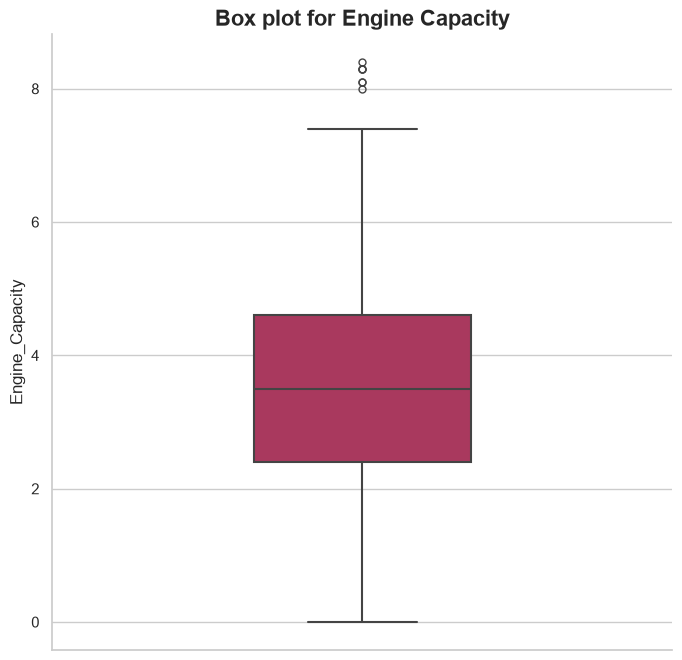

In [62]:
sns.set_theme(style='whitegrid')

fig,axes=plt.subplots(figsize=(8,8))

sns.boxplot(
    y=df["Engine_Capacity"],
    color="#BC2658",
    width=0.35,
    linewidth=1.5,
    fliersize=5,
    ax=axes
)

axes.set_title("Box plot for Engine Capacity",fontsize=16,fontweight='bold')
axes.set_ylabel("Engine_Capacity")
axes.set_xlabel("")

sns.despine()
plt.tight_layout(rect=[0,0.97,1,1])
plt.show()

In [63]:
df['Engine_Capacity']= df['Engine_Capacity'].fillna(df['Engine_Capacity'].median())

In [66]:
missing_info={}
for col in Numerical_columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,2)
print("\n The categorical columns with the missing percentage are:\n")
for col, per in missing_info.items():
    print(f"{col}:{per}%")


 The categorical columns with the missing percentage are:

Horse_Power:20.15%
